# Hourly GLORYS12V1 currents (T/U/V) for Cabo Verde


In [1]:
import os
import time
import glob
import threading

import requests
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

from pydap.client import open_url
from xarray.backends import PydapDataStore
import pydap.net as pydap_net
import pydap.handlers.dap as dap_module

from concurrent.futures import ThreadPoolExecutor, as_completed

## Config

In [2]:
CA_BUNDLE = "/home/b/b384140/combined_ca_bundle.pem"
AUTHELIA_COOKIE = "8#_-um^f8oK_uy$rVKtxiT2akGmQb957"  # refresh if it's been a while

LON_MIN, LON_MAX = -30,-16
LAT_MIN, LAT_MAX = 12,20

START_DATE = "2020-01-01"
END_DATE   = "2020-01-11"

OUT_DIR = "../data/"
os.makedirs(OUT_DIR, exist_ok=True)

BASE = "https://tds.mercator-ocean.fr/thredds/dodsC"

# Confirmed via catalog crawl (see 002_download_hourly.ipynb Step 1 pattern):
#   MOI GLORYS12 [GLORYS12V1] > [PGN Hourly]
#     glorys12v1-hourly-gridT / gridU / gridV
DATASETS = {
    "gridT": f"{BASE}/glorys12v1-hourly-gridT",
    "gridU": f"{BASE}/glorys12v1-hourly-gridU",
    "gridV": f"{BASE}/glorys12v1-hourly-gridV",
}

GRID_VARS_HINT = {
    "gridT": None,
    "gridU": ["vozocrtx", "uo", "sozocrtx"],
    "gridV": ["vomecrty", "vo", "somecrty"],
}

# Same static files you already used from the PSY4V3R1 side, re-exposed
# under the glorys12v1 catalog folder (identical content):
MASK_URL     = f"{BASE}/glorys12v1_statics/PSY4V3R1_mask.nc"
MESH_HGR_URL = f"{BASE}/glorys12v1_statics/PSY4V3R1_mesh_hgr.nc"

MAX_WORKERS = 12  # keep conservative -- hourly requests are heavier per file


## Session / auth helpers

In [3]:
def make_session():
    s = requests.Session()
    s.verify = CA_BUNDLE
    s.cookies.set("authelia_session", AUTHELIA_COOKIE, domain="tds.mercator-ocean.fr")
    return s


def make_reliable_GET(session_for_thread):
    def reliable_GET(url, application=None, session=None, timeout=300, verify=True, get_kwargs=None):
        last_err = None
        for attempt in range(5):
            try:
                r = session_for_thread.get(url, timeout=timeout)
                if r.text[:15].strip().startswith(("<!doctype", "<html")):
                    raise RuntimeError("Cookie expired mid-request -- refresh AUTHELIA_COOKIE.")
                return r
            except Exception as e:
                last_err = e
                time.sleep(5 * (attempt + 1))
        raise last_err
    return reliable_GET


def pick_data_var(ds, hints):
    if hints:
        for h in hints:
            if h in ds.data_vars:
                return h
    for name, da in ds.data_vars.items():
        if "x" in da.dims and "y" in da.dims:
            return name
    raise ValueError("No suitable data variable found.")


## Probe the dataset

In [4]:
probe_session = make_session()
pydap_net.GET = make_reliable_GET(probe_session)
dap_module.GET = pydap_net.GET

print("Probing gridT:", DATASETS["gridT"])
pdap = open_url(DATASETS["gridT"], session=probe_session, protocol="dap2", checksums=False)
ds_probe = xr.open_dataset(PydapDataStore(pdap))

lon2d = ds_probe["nav_lon"].values
lat2d = ds_probe["nav_lat"].values
box_mask = (lon2d >= LON_MIN) & (lon2d <= LON_MAX) & (lat2d >= LAT_MIN) & (lat2d <= LAT_MAX)
j_idx, i_idx = np.where(box_mask)
j_slice = slice(int(j_idx.min()), int(j_idx.max()) + 1)
i_slice = slice(int(i_idx.min()), int(i_idx.max()) + 1)
print("Index box:", j_slice, i_slice)

time_dim = "time_counter" if "time_counter" in ds_probe.dims else "time"
print(f"Detected time dimension: '{time_dim}'")

t = pd.to_datetime(ds_probe[time_dim].values[:6]) if np.issubdtype(ds_probe[time_dim].dtype, np.datetime64) else ds_probe[time_dim].values[:6]
print("First few time values:", t)
if hasattr(t, "to_series"):
    diffs = pd.Series(t).diff().dropna()
    print("Spacing between steps:", diffs.tolist())
print("^ Confirm spacing is ~1 hour before proceeding to the download below.")


Probing gridT: https://tds.mercator-ocean.fr/thredds/dodsC/glorys12v1-hourly-gridT
Index box: slice(1640, 1740, None) slice(3085, 3254, None)
Detected time dimension: 'time_counter'
First few time values: DatetimeIndex(['1993-01-01 00:30:00', '1993-01-01 01:30:00',
               '1993-01-01 02:30:00', '1993-01-01 03:30:00',
               '1993-01-01 04:30:00', '1993-01-01 05:30:00'],
              dtype='datetime64[ns]', freq=None)
Spacing between steps: [Timedelta('0 days 01:00:00'), Timedelta('0 days 01:00:00'), Timedelta('0 days 01:00:00'), Timedelta('0 days 01:00:00'), Timedelta('0 days 01:00:00')]
^ Confirm spacing is ~1 hour before proceeding to the download below.


## Download, chunked by day

In [5]:
write_lock = threading.Lock()

def download_one(grid_name, url, day, j_slice, i_slice, time_dim):
    day_str = day.strftime("%Y-%m-%d")
    out_path = f"{OUT_DIR}/{grid_name}_cabo_verde_{day_str}.nc"

    if os.path.exists(out_path):
        return (grid_name, day_str, "skipped")

    thread_session = make_session()
    reliable_GET = make_reliable_GET(thread_session)
    pydap_net.GET = reliable_GET
    dap_module.GET = reliable_GET

    try:
        pdap_ds = open_url(url, session=thread_session, protocol="dap2", checksums=False)
        ds = xr.open_dataset(PydapDataStore(pdap_ds))
        sub = ds.isel(y=j_slice, x=i_slice)

        time_vals = sub[time_dim].values
        mask = np.array([(t.year, t.month, t.day) == (day.year, day.month, day.day) for t in pd.to_datetime(time_vals)])
        sub = sub.isel({time_dim: mask})

        if sub.sizes.get(time_dim, 0) == 0:
            return (grid_name, day_str, "no_data")

        sub = sub.sortby(time_dim)
        _, unique_idx = np.unique(sub[time_dim].values, return_index=True)
        sub = sub.isel({time_dim: np.sort(unique_idx)})

        if grid_name != "gridT":
            varname = pick_data_var(sub, GRID_VARS_HINT.get(grid_name))
            keep = [varname] + [v for v in ("nav_lon", "nav_lat") if v in sub]
            sub = sub[keep]

        sub.load()  # network read -- safe to parallelize

        with write_lock:  # local HDF5 write -- must be serialized
            sub.to_netcdf(out_path)

        return (grid_name, day_str, "done")

    except Exception as e:
        return (grid_name, day_str, f"FAILED: {e}")


In [6]:
days = pd.date_range(START_DATE, END_DATE, freq="D")
urls = {name: url for name, url in DATASETS.items()}

tasks = [(g, url, d) for g, url in urls.items() for d in days]
print(f"\n{len(tasks)} tasks ({len(days)} days x {len(urls)} grids), {MAX_WORKERS} workers")

results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
    futures = {
        ex.submit(download_one, g, url, d, j_slice, i_slice, time_dim): (g, d)
        for g, url, d in tasks
    }
    for fut in as_completed(futures):
        g, d = futures[fut]
        status = fut.result()
        print(f"  {status[0]} {status[1]}: {status[2]}")
        results.append(status)

failed = [(g, d, s) for g, d, s in results if s.startswith("FAILED")]
print(f"\n=== Done. {len(results) - len(failed)}/{len(results)} succeeded ===")
if failed:
    print("Rerun this cell -- completed files are skipped, only failures retry.")



33 tasks (11 days x 3 grids), 12 workers


HDF5-DIAG: Error detected in HDF5 (2.1.0) thread 2:
  #000: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5F.c line 490 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLcallback.c line 4109 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLcallback.c line 4045 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: /home/conda/feedstock_root/build_artifacts/hdf5_17778611834

  gridT 2020-01-08: done


HDF5-DIAG: Error detected in HDF5 (2.1.0) thread 3:
  #000: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5F.c line 490 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLcallback.c line 4109 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLcallback.c line 4045 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: /home/conda/feedstock_root/build_artifacts/hdf5_17778611834

  gridT 2020-01-01: done


...

HDF5-DIAG: Error detected in HDF5 (2.1.0) thread 11:
  #000: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5F.c line 490 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLcallback.c line 4109 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLcallback.c line 4045 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183

  gridV 2020-01-10: done


HDF5-DIAG: Error detected in HDF5 (2.1.0) thread 13:
  #000: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5F.c line 490 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLcallback.c line 4109 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLcallback.c line 4045 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183

  gridU 2020-01-01: done
  gridU 2020-01-09: done

=== Done. 33/33 succeeded ===


HDF5-DIAG: Error detected in HDF5 (2.1.0) thread 9:
  #000: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5F.c line 490 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLcallback.c line 4109 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLcallback.c line 4045 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: /home/conda/feedstock_root/build_artifacts/hdf5_1777861183421/work/src/H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: /home/conda/feedstock_root/build_artifacts/hdf5_17778611834

## Combine T/U/V into one file

In [7]:
def combine_grid(grid_name, lon_name, lat_name):
    files = sorted(glob.glob(f"{OUT_DIR}/{grid_name}_cabo_verde_*.nc"))
    print(f"{grid_name}: combining {len(files)} daily files")
    ds = xr.open_mfdataset(
        files,
        combine="nested",          # <- was "by_coords"
        concat_dim="time_counter", # <- explicitly tell it what to stack on
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=True,             # optional: speeds up 2192-file open
    )
    ds = ds.rename({"nav_lon": lon_name, "nav_lat": lat_name})
    return ds

dsT = combine_grid("gridT", "lon_t", "lat_t")
dsU = combine_grid("gridU", "lon_u", "lat_u")
dsV = combine_grid("gridV", "lon_v", "lat_v")

combined = xr.merge([dsT, dsU, dsV], compat="override", join="exact")
print(combined)

OUT_FILE = f"{OUT_DIR}/cabo_verde_jan_20.nc"
combined.to_netcdf(OUT_FILE)
print("Saved:", OUT_FILE)

gridT: combining 11 daily files
gridU: combining 11 daily files
gridV: combining 11 daily files
<xarray.Dataset> Size: 179MB
Dimensions:       (time_counter: 264, deptht: 1, y: 100, x: 169)
Coordinates:
  * deptht        (deptht) float32 4B 0.0
  * x             (x) int32 676B 3086 3087 3088 3089 ... 3251 3252 3253 3254
  * y             (y) int32 400B 1641 1642 1643 1644 ... 1737 1738 1739 1740
  * time_counter  (time_counter) datetime64[ns] 2kB 2020-01-01T00:30:00 ... 2...
    lon_t         (y, x) float32 68kB dask.array<chunksize=(100, 169), meta=np.ndarray>
    lat_t         (y, x) float32 68kB dask.array<chunksize=(100, 169), meta=np.ndarray>
    lon_u         (y, x) float32 68kB dask.array<chunksize=(100, 169), meta=np.ndarray>
    lat_u         (y, x) float32 68kB dask.array<chunksize=(100, 169), meta=np.ndarray>
    lon_v         (y, x) float32 68kB dask.array<chunksize=(100, 169), meta=np.ndarray>
    lat_v         (y, x) float32 68kB dask.array<chunksize=(100, 169), meta=np.n

## Apply the real land mask + attach native mesh geometry

In [8]:
mask_session = make_session()
pydap_net.GET = make_reliable_GET(mask_session)
dap_module.GET = pydap_net.GET

pdap_mask = open_url(MASK_URL, session=mask_session, protocol="dap2", checksums=False)
mask_full = xr.open_dataset(PydapDataStore(pdap_mask))
print(mask_full.data_vars)

mask_sub = mask_full.isel(y=j_slice, x=i_slice, t=0)

umask = mask_sub["umaskutil"].values.astype(bool)  # True = ocean, on the U grid
vmask = mask_sub["vmaskutil"].values.astype(bool)  # True = ocean, on the V grid

print("umask shape:", umask.shape, " ocean fraction:", umask.mean())
print("vmask shape:", vmask.shape, " ocean fraction:", vmask.mean())

Data variables:
    nav_lon       (y, x) float32 53MB ...
    nav_lat       (y, x) float32 53MB ...
    nav_lev       (z) float32 200B ...
    time_counter  (t) float64 8B ...
    tmask         (t, z, y, x) int8 661MB ...
    umask         (t, z, y, x) int8 661MB ...
    vmask         (t, z, y, x) int8 661MB ...
    fmask         (t, z, y, x) int8 661MB ...
    tmaskutil     (t, y, x) int8 13MB ...
    umaskutil     (t, y, x) int8 13MB ...
    vmaskutil     (t, y, x) int8 13MB ...
    fmaskutil     (t, y, x) int8 13MB ...
umask shape: (100, 169)  ocean fraction: 0.9530177514792899
vmask shape: (100, 169)  ocean fraction: 0.9573964497041421


In [9]:
mesh_session = make_session()
pydap_net.GET = make_reliable_GET(mesh_session)
dap_module.GET = pydap_net.GET

pdap_mesh = open_url(MESH_HGR_URL, session=mesh_session, protocol="dap2", checksums=False)
mesh = xr.open_dataset(PydapDataStore(pdap_mesh))

mesh_sub = mesh.isel(y=j_slice, x=i_slice)
if "t" in mesh_sub.dims:
    mesh_sub = mesh_sub.isel(t=0)   # mesh vars carry a singleton time dim -- squeeze it

lon_t_mesh, lat_t_mesh = mesh_sub["glamt"].values, mesh_sub["gphit"].values  # T-point (centers)
lon_f_mesh, lat_f_mesh = mesh_sub["glamf"].values, mesh_sub["gphif"].values  # F-point (corners)

print("lon_f shape:", lon_f_mesh.shape, "-- should match (len(j_slice), len(i_slice))")

# sanity check: T-point mesh coords should match the T-grid coords you
# actually downloaded
ds_check = xr.open_dataset(OUT_FILE)
print("max |lon_t mesh - lon_t data| =", np.nanmax(np.abs(lon_t_mesh - ds_check["lon_t"].values)))
print("max |lat_t mesh - lat_t data| =", np.nanmax(np.abs(lat_t_mesh - ds_check["lat_t"].values)))

lon_f shape: (100, 169) -- should match (len(j_slice), len(i_slice))
max |lon_t mesh - lon_t data| = 0.0
max |lat_t mesh - lat_t data| = 0.0


In [10]:
ds = xr.open_dataset(OUT_FILE)

u_vals = ds["sozocrtx"].values          # (time, deptht, y, x)
v_vals = ds["somecrty"].values
#u_vals[..., ~umask] = 0.0
#v_vals[..., ~vmask] = 0.0

ds["sozocrtx"] = (ds["sozocrtx"].dims, u_vals, ds["sozocrtx"].attrs)
ds["somecrty"] = (ds["somecrty"].dims, v_vals, ds["somecrty"].attrs)

ds = ds.assign_coords(
    lon_f=(("y", "x"), lon_f_mesh),
    lat_f=(("y", "x"), lat_f_mesh),
)

OUT_FILE_MASKED = f"{OUT_DIR}/cabo_verde_jan_20_landmasked.nc"
ds.to_netcdf(OUT_FILE_MASKED)
print("Saved:", OUT_FILE_MASKED)

Saved: ../data//cabo_verde_jan_20_landmasked.nc


## Sanity-check plot

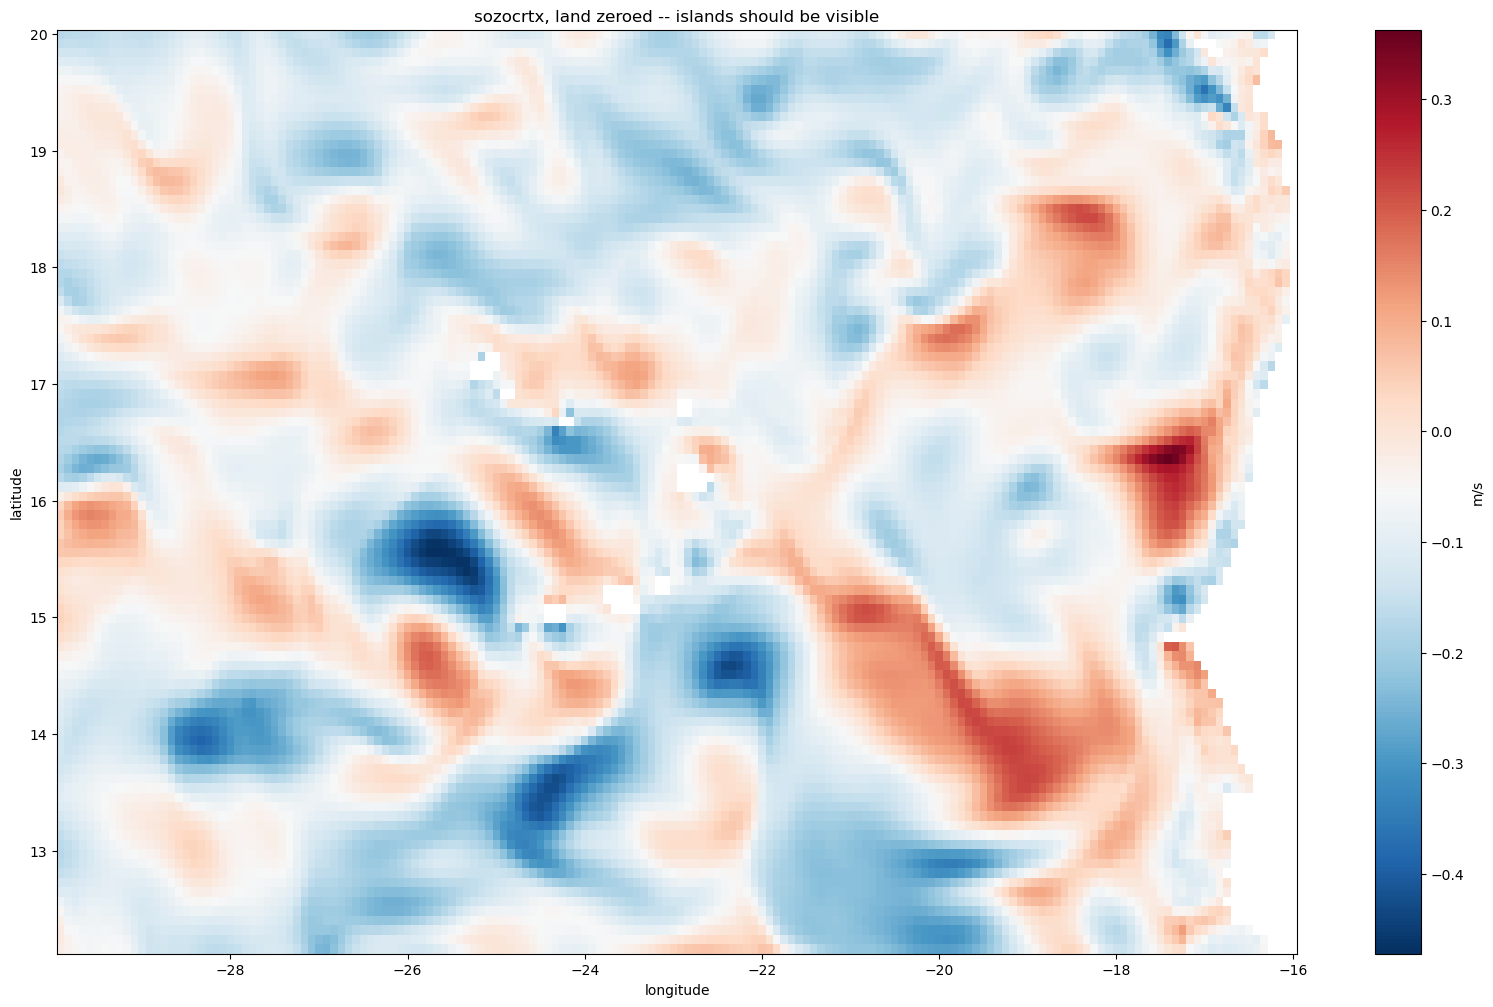

In [11]:
fig, ax = plt.subplots(figsize=(20, 12))
u0 = np.where(umask, ds["sozocrtx"].isel(time_counter=0, deptht=0).values, np.nan)
mesh_plot = ax.pcolormesh(ds["lon_f"], ds["lat_f"], u0[:-1, :-1], cmap="RdBu_r")
ax.set_title("sozocrtx, land zeroed -- islands should be visible")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
plt.colorbar(mesh_plot, ax=ax, label="m/s")
plt.show()